<a href="https://colab.research.google.com/github/RajeshworM/Yield_Modelling_Automation/blob/main/wt_prod_act_vs_est.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving file_actualvsestimated.xlsx to file_actualvsestimated.xlsx


/tmp/ipykernel_1251/275388303.py:92: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'weighted_actual': df.groupby('year').apply(
/tmp/ipykernel_1251/275388303.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'weighted_estimated': df.groupby('year').apply(



STATE-LEVEL WEIGHTED TIME SERIES

    year  weighted_actual  weighted_estimated
0   2010      1223.491723         1152.305391
1   2011      1203.656224         1011.951729
2   2012      1457.730962         1298.155436
3   2013       862.617708          693.142017
4   2014      1258.029065         1168.407536
5   2015       833.544759          812.754906
6   2016      1327.181712         1252.334584
7   2017      1150.612874          967.701671
8   2018      1135.367053          992.416678
9   2019       748.306056          668.742561
10  2020       568.277813          579.764433
11  2021      1062.853109          911.442993
12  2022      1103.830905         1085.210379
13  2023       932.517150          931.096797
14  2024       946.394783          979.776282
15  2025              NaN         1160.663701


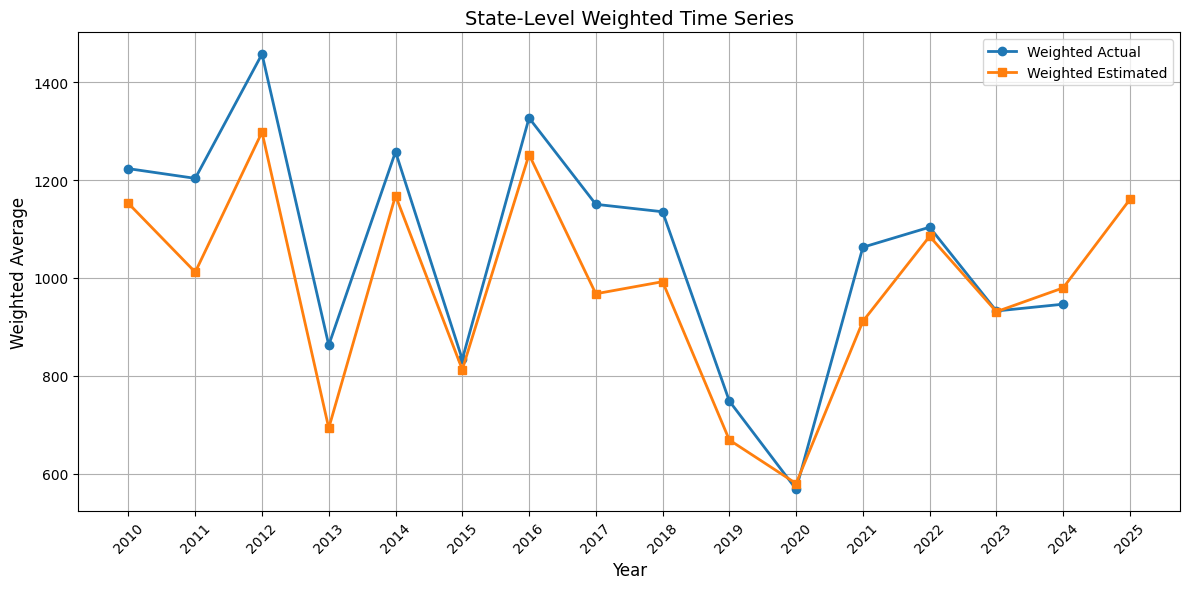

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================
# STATE-LEVEL WEIGHTED TIME SERIES
# USING DISTRICT PRODUCTION AS WEIGHTS
# Special Rule:
# If 2025 production is missing,
# use 2024 production of same district
# ============================================

# Install openpyxl if needed
# !pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# ============================================
# UPLOAD EXCEL FILE
# ============================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# ============================================
# CLEAN COLUMN NAMES
# ============================================

df.columns = df.columns.str.strip().str.lower()

# ============================================
# CONVERT TO NUMERIC
# ============================================

numeric_cols = ['year', 'actual', 'estimated', 'prod']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ============================================
# FILL 2025 PRODUCTION USING 2024 VALUES
# ============================================

# Create lookup table for 2024 production
prod_2024 = (
    df[df['year'] == 2024][['district', 'prod']]
    .rename(columns={'prod': 'prod_2024'})
)

# Merge lookup
df = df.merge(prod_2024, on='district', how='left')

# Replace missing 2025 production
mask = (df['year'] == 2025) & (df['prod'].isna())

df.loc[mask, 'prod'] = df.loc[mask, 'prod_2024']

# Drop helper column
df.drop(columns=['prod_2024'], inplace=True)

# ============================================
# REMOVE ROWS WITHOUT PRODUCTION
# ============================================

df = df.dropna(subset=['prod'])

# ============================================
# WEIGHTED AVERAGE FUNCTION
# ============================================

def weighted_avg(group, value_col, weight_col='prod'):

    d = group[[value_col, weight_col]].dropna()

    if len(d) == 0:
        return np.nan

    return (
        (d[value_col] * d[weight_col]).sum()
        / d[weight_col].sum()
    )

# ============================================
# CREATE STATE-LEVEL TIME SERIES
# ============================================

state_ts = pd.DataFrame({

    'weighted_actual': df.groupby('year').apply(
        lambda x: weighted_avg(x, 'actual')
    ),

    'weighted_estimated': df.groupby('year').apply(
        lambda x: weighted_avg(x, 'estimated')
    )

}).reset_index()

# ============================================
# DISPLAY RESULT
# ============================================

print("\nSTATE-LEVEL WEIGHTED TIME SERIES\n")
print(state_ts)

# ============================================
# SAVE OUTPUT
# ============================================

state_ts.to_excel(
    'state_weighted_timeseries.xlsx',
    index=False
)

# ============================================
# LINE GRAPH
# ============================================

plt.figure(figsize=(12,6))

plt.plot(
    state_ts['year'],
    state_ts['weighted_actual'],
    marker='o',
    linewidth=2,
    label='Weighted Actual'
)

plt.plot(
    state_ts['year'],
    state_ts['weighted_estimated'],
    marker='s',
    linewidth=2,
    label='Weighted Estimated'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Average', fontsize=12)

plt.title(
    'State-Level Weighted Time Series',
    fontsize=14
)

plt.xticks(state_ts['year'], rotation=45)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================
# DOWNLOAD OUTPUT FILE
# ============================================

files.download('state_weighted_timeseries.xlsx')